In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import joblib
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score, classification_report, confusion_matrix, make_scorer
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')


In [9]:
# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.3f}'.format)

# Set style for plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("Starting Model Development...")

Starting Model Development...


In [10]:
# Create necessary directories
os.makedirs('../models', exist_ok=True)
os.makedirs('../reports/figures', exist_ok=True)
os.makedirs('../data/submissions', exist_ok=True)

# Load the engineered data
train_path = '../data/processed/train_engineered.csv'
test_path = '../data/processed/test_engineered.csv'
sample_submission_path = '../data/raw/sample_submission.csv'

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
sample_submission = pd.read_csv(sample_submission_path)

print(f"Train data shape: {train.shape}")
print(f"Test data shape: {test.shape}")
print(f"Sample submission shape: {sample_submission.shape}")

Train data shape: (13998, 46)
Test data shape: (6000, 45)
Sample submission shape: (6000, 2)



Target variable distribution:
Data Quality
Fair              10133
Unknown            3590
Good                251
Pending review       24
Name: count, dtype: int64


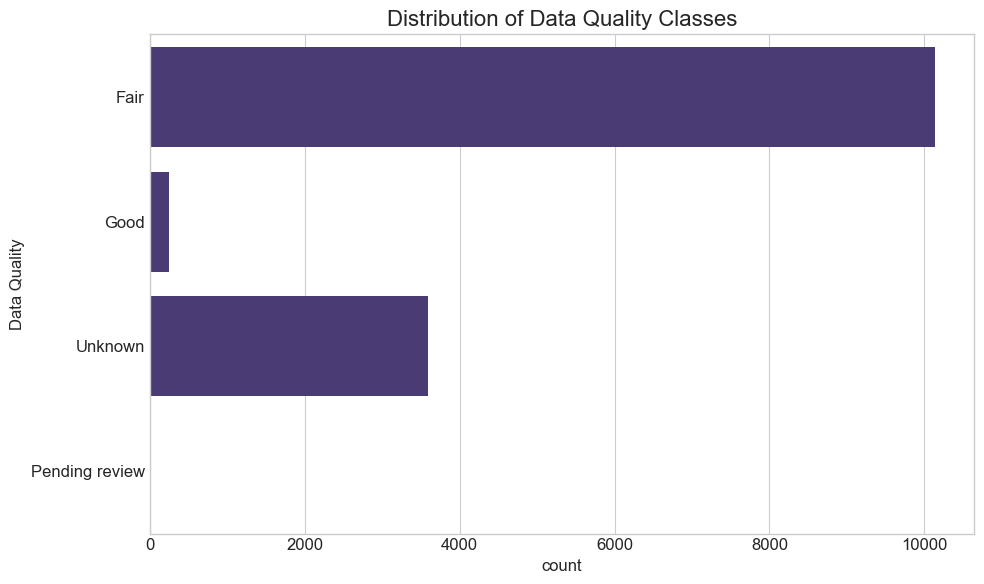

In [11]:
# Check the target variable distribution again
if 'Data Quality' in train.columns:
    print("\nTarget variable distribution:")
    target_counts = train['Data Quality'].value_counts()
    print(target_counts)
    
    # Visualize target distribution
    plt.figure(figsize=(10, 6))
    sns.countplot(y='Data Quality', data=train)
    plt.title('Distribution of Data Quality Classes', fontsize=16)
    plt.tight_layout()
    plt.savefig('../reports/figures/target_distribution_final.png')
    plt.show()
else:
    print("Error: Target variable 'Data Quality' not found in training data!")
    exit()

In [12]:
# ==========================================
# PREPARE DATA FOR MODELING
# ==========================================
print("\n" + "="*50)
print("PREPARING DATA FOR MODELING")
print("="*50)

# Encode target variable
le = LabelEncoder()
y = le.fit_transform(train['Data Quality'])
X = train.drop('Data Quality', axis=1)

# Save label encoder for later use
joblib.dump(le, '../models/label_encoder.pkl')
print(f"Label Encoder saved to '../models/label_encoder.pkl'")

# Print target class mapping
print("\nTarget class mapping:")
for i, label in enumerate(le.classes_):
    print(f"  {label} -> {i}")

# Split data into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")

# Check for any remaining string/object columns
obj_cols = X.select_dtypes(include=['object']).columns.tolist()
if obj_cols:
    print(f"\nWarning: {len(obj_cols)} object columns found: {obj_cols}")
    print("These should be encoded before modeling.")
else:
    print("\nAll features are numeric - ready for modeling.")


PREPARING DATA FOR MODELING
Label Encoder saved to '../models/label_encoder.pkl'

Target class mapping:
  Fair -> 0
  Good -> 1
  Pending review -> 2
  Unknown -> 3

Training set: (11198, 45)
Validation set: (2800, 45)

All features are numeric - ready for modeling.



BASELINE MODELS

Evaluating baseline models on validation set...
  Random Forest:
    - Macro F1: 0.7130
    - Training time: 2.85 seconds
  XGBoost:
    - Macro F1: 0.7223
    - Training time: 0.50 seconds
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001623 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7257
[LightGBM] [Info] Number of data points in the train set: 11198, number of used features: 45
[LightGBM] [Info] Start training from score -0.323131
[LightGBM] [Info] Start training from score -4.020186
[LightGBM] [Info] Start training from score -6.379051
[LightGBM] [Info] Start training from score -1.360727
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

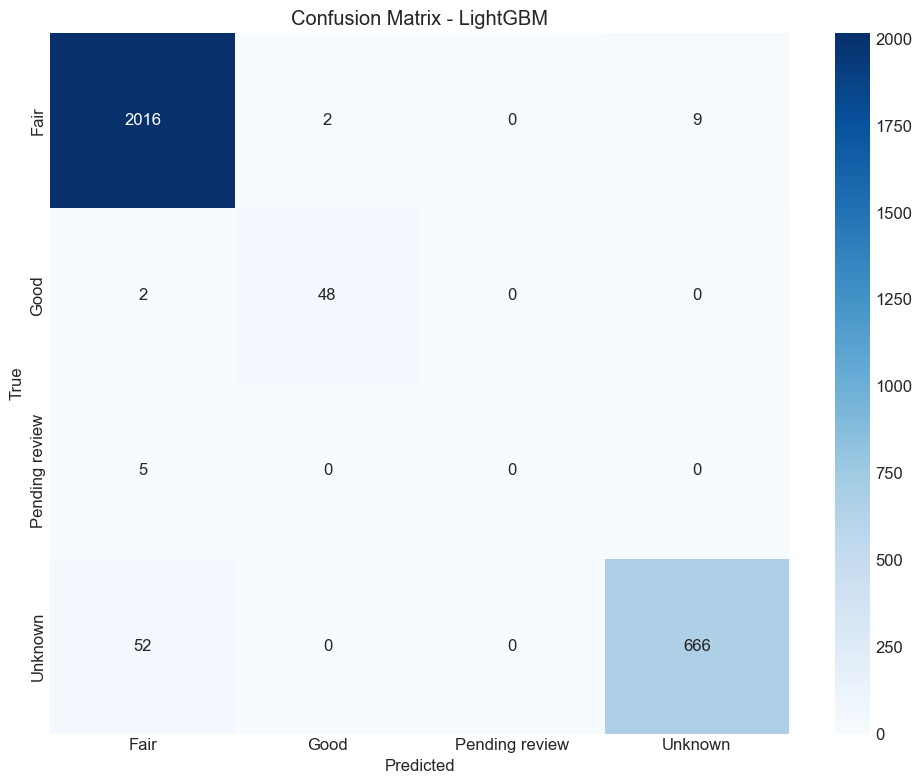

In [13]:
# ==========================================
# BASELINE MODELS
# ==========================================
print("\n" + "="*50)
print("BASELINE MODELS")
print("="*50)

# Define the custom evaluation metric: macro-averaged F1
def macro_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, average='macro')

# Create a scorer for model evaluation
macro_f1_scorer = make_scorer(macro_f1)

# Import models here to avoid potential issues with scikit-learn versions
from sklearn.ensemble import RandomForestClassifier
# Try to import XGBoost, handle if not available
try:
    import xgboost as xgb
    has_xgboost = True
except ImportError:
    print("XGBoost not available, will use RandomForest only")
    has_xgboost = False

# Try to import LightGBM, handle if not available
try:
    import lightgbm as lgb
    has_lightgbm = True
except ImportError:
    print("LightGBM not available, will use other models")
    has_lightgbm = False

# Define baseline models with available libraries
baseline_models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# Add XGBoost if available
if has_xgboost:
    baseline_models['XGBoost'] = xgb.XGBClassifier(n_estimators=100, random_state=42)

# Add LightGBM if available
if has_lightgbm:
    baseline_models['LightGBM'] = lgb.LGBMClassifier(n_estimators=100, random_state=42)

# Train and evaluate baseline models directly (avoid cross_val_score for compatibility)
baseline_results = {}
print("\nEvaluating baseline models on validation set...")

for name, model in baseline_models.items():
    start_time = time.time()
    
    # Train the model on the training set
    model.fit(X_train, y_train)
    
    # Predict on validation set
    y_pred = model.predict(X_val)
    
    # Calculate macro F1
    f1 = macro_f1(y_val, y_pred)
    
    training_time = time.time() - start_time
    
    baseline_results[name] = {
        'f1': f1,
        'training_time': training_time
    }
    
    print(f"  {name}:")
    print(f"    - Macro F1: {f1:.4f}")
    print(f"    - Training time: {training_time:.2f} seconds")

# Find the best baseline model
best_baseline = max(baseline_results.items(), key=lambda x: x[1]['f1'])
print(f"\nBest baseline model: {best_baseline[0]} (Macro F1: {best_baseline[1]['f1']:.4f})")

# Get the best baseline model
best_baseline_model = baseline_models[best_baseline[0]]

# Print detailed evaluation
print("\nValidation set performance:")
print(f"  Macro F1: {best_baseline[1]['f1']:.4f}")
print("\nClassification Report:")
y_pred = best_baseline_model.predict(X_val)
print(classification_report(y_val, y_pred, target_names=le.classes_))

# Plot confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix - {best_baseline[0]}')
plt.tight_layout()
plt.savefig(f'../reports/figures/confusion_matrix_baseline.png')
plt.show()

In [14]:
# ==========================================
# HANDLE CLASS IMBALANCE
# ==========================================
print("\n" + "="*50)
print("HANDLING CLASS IMBALANCE")
print("="*50)

# Check if SMOTE is available
try:
    from imblearn.over_sampling import SMOTE
    has_smote = True
except ImportError:
    print("SMOTE not available, using class weights instead")
    has_smote = False

if has_smote:
    # Apply SMOTE to address class imbalance
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    
    print(f"Original training set shape: {X_train.shape}")
    print(f"Resampled training set shape: {X_train_resampled.shape}")
    
    # Check the target distribution after SMOTE
    unique, counts = np.unique(y_train_resampled, return_counts=True)
    print("\nTarget distribution after SMOTE:")
    for value, count in zip(unique, counts):
        print(f"  Class {le.inverse_transform([value])[0]}: {count}")
else:
    # Use the original data but calculate class weights
    from sklearn.utils.class_weight import compute_class_weight
    
    class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
    class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
    
    print("\nUsing class weights instead of SMOTE:")
    for class_idx, weight in class_weight_dict.items():
        print(f"  Class {le.inverse_transform([class_idx])[0]}: {weight:.4f}")
    
    # For consistency in later code
    X_train_resampled = X_train.copy()
    y_train_resampled = y_train.copy()


HANDLING CLASS IMBALANCE
Original training set shape: (11198, 45)
Resampled training set shape: (32424, 45)

Target distribution after SMOTE:
  Class Fair: 8106
  Class Good: 8106
  Class Pending review: 8106
  Class Unknown: 8106


In [15]:
# ==========================================
# MODEL TUNING
# ==========================================
print("\n" + "="*50)
print("MODEL TUNING")
print("="*50)

# Check if optuna is available for hyperparameter tuning
try:
    import optuna
    has_optuna = True
except ImportError:
    print("Optuna not available, using grid search instead")
    has_optuna = False

# Define tuned models using the best baseline approach
tuned_models = {}

# Random Forest tuning
print("\nTuning Random Forest...")
if has_optuna:
    # Define the objective function for Optuna
    def objective_rf(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'max_depth': trial.suggest_int('max_depth', 3, 15),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
            'random_state': 42
        }
        
        model = RandomForestClassifier(**params)
        model.fit(X_train_resampled, y_train_resampled)
        y_pred = model.predict(X_val)
        return macro_f1(y_val, y_pred)
    
    # Create the study and optimize
    study_rf = optuna.create_study(direction='maximize')
    study_rf.optimize(objective_rf, n_trials=20)
    
    # Get the best parameters
    best_rf_params = study_rf.best_params
    best_rf_score = study_rf.best_value
    
    # Create the tuned model
    tuned_rf = RandomForestClassifier(**best_rf_params, random_state=42)
    tuned_rf.fit(X_train_resampled, y_train_resampled)
    
    print(f"  Best Random Forest Macro F1: {best_rf_score:.4f}")
    print("  Best Random Forest parameters:")
    for param, value in best_rf_params.items():
        print(f"    {param}: {value}")
else:
    # Simple manual tuning
    from sklearn.model_selection import GridSearchCV
    
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 15],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    }
    
    grid_search = GridSearchCV(
        RandomForestClassifier(random_state=42),
        param_grid,
        cv=3,
        scoring=macro_f1_scorer,
        n_jobs=-1
    )
    
    grid_search.fit(X_train_resampled, y_train_resampled)
    
    best_rf_params = grid_search.best_params_
    best_rf_score = grid_search.best_score_
    
    # Create the tuned model
    tuned_rf = grid_search.best_estimator_
    
    print(f"  Best Random Forest Macro F1: {best_rf_score:.4f}")
    print("  Best Random Forest parameters:")
    for param, value in best_rf_params.items():
        print(f"    {param}: {value}")

# Store the tuned Random Forest model
tuned_models['Random Forest'] = tuned_rf

# If XGBoost is available, tune it
if has_xgboost:
    print("\nTuning XGBoost...")
    if has_optuna:
        def objective_xgb(trial):
            params = {
                'max_depth': trial.suggest_int('max_depth', 3, 10),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                'n_estimators': trial.suggest_int('n_estimators', 50, 300),
                'subsample': trial.suggest_float('subsample', 0.5, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
                'random_state': 42
            }
            
            model = xgb.XGBClassifier(**params)
            model.fit(X_train_resampled, y_train_resampled)
            y_pred = model.predict(X_val)
            return macro_f1(y_val, y_pred)
        
        study_xgb = optuna.create_study(direction='maximize')
        study_xgb.optimize(objective_xgb, n_trials=20)
        
        best_xgb_params = study_xgb.best_params
        best_xgb_score = study_xgb.best_value
        
        tuned_xgb = xgb.XGBClassifier(**best_xgb_params, random_state=42)
        tuned_xgb.fit(X_train_resampled, y_train_resampled)
        
        print(f"  Best XGBoost Macro F1: {best_xgb_score:.4f}")
        print("  Best XGBoost parameters:")
        for param, value in best_xgb_params.items():
            print(f"    {param}: {value}")
    else:
        # Simple manual tuning
        param_grid = {
            'max_depth': [3, 6, 9],
            'learning_rate': [0.01, 0.1, 0.2],
            'n_estimators': [100, 200]
        }
        
        grid_search = GridSearchCV(
            xgb.XGBClassifier(random_state=42),
            param_grid,
            cv=3,
            scoring=macro_f1_scorer,
            n_jobs=-1
        )
        
        grid_search.fit(X_train_resampled, y_train_resampled)
        
        best_xgb_params = grid_search.best_params_
        best_xgb_score = grid_search.best_score_
        
        tuned_xgb = grid_search.best_estimator_
        
        print(f"  Best XGBoost Macro F1: {best_xgb_score:.4f}")
        print("  Best XGBoost parameters:")
        for param, value in best_xgb_params.items():
            print(f"    {param}: {value}")
    
    # Store the tuned XGBoost model
    tuned_models['XGBoost'] = tuned_xgb

# If LightGBM is available, tune it
if has_lightgbm:
    print("\nTuning LightGBM...")
    if has_optuna:
        def objective_lgb(trial):
            params = {
                'num_leaves': trial.suggest_int('num_leaves', 20, 150),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                'n_estimators': trial.suggest_int('n_estimators', 50, 300),
                'subsample': trial.suggest_float('subsample', 0.5, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
                'random_state': 42
            }
            
            model = lgb.LGBMClassifier(**params)
            model.fit(X_train_resampled, y_train_resampled)
            y_pred = model.predict(X_val)
            return macro_f1(y_val, y_pred)
        
        study_lgb = optuna.create_study(direction='maximize')
        study_lgb.optimize(objective_lgb, n_trials=20)
        
        best_lgb_params = study_lgb.best_params
        best_lgb_score = study_lgb.best_value
        
        tuned_lgb = lgb.LGBMClassifier(**best_lgb_params, random_state=42)
        tuned_lgb.fit(X_train_resampled, y_train_resampled)
        
        print(f"  Best LightGBM Macro F1: {best_lgb_score:.4f}")
        print("  Best LightGBM parameters:")
        for param, value in best_lgb_params.items():
            print(f"    {param}: {value}")
    else:
        # Simple manual tuning
        param_grid = {
            'num_leaves': [31, 50, 100],
            'learning_rate': [0.01, 0.1],
            'n_estimators': [100, 200]
        }
        
        grid_search = GridSearchCV(
            lgb.LGBMClassifier(random_state=42),
            param_grid,
            cv=3,
            scoring=macro_f1_scorer,
            n_jobs=-1
        )
        
        grid_search.fit(X_train_resampled, y_train_resampled)
        
        best_lgb_params = grid_search.best_params_
        best_lgb_score = grid_search.best_score_
        
        tuned_lgb = grid_search.best_estimator_
        
        print(f"  Best LightGBM Macro F1: {best_lgb_score:.4f}")
        print("  Best LightGBM parameters:")
        for param, value in best_lgb_params.items():
            print(f"    {param}: {value}")
    
    # Store the tuned LightGBM model
    tuned_models['LightGBM'] = tuned_lgb


[I 2025-05-02 01:10:05,322] A new study created in memory with name: no-name-a41fa5f9-84a5-4654-80b8-2674fa5ea910



MODEL TUNING

Tuning Random Forest...


[I 2025-05-02 01:10:17,215] Trial 0 finished with value: 0.6828548231800552 and parameters: {'n_estimators': 246, 'max_depth': 5, 'min_samples_split': 6, 'min_samples_leaf': 10, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.6828548231800552.
[I 2025-05-02 01:10:21,565] Trial 1 finished with value: 0.718672847338451 and parameters: {'n_estimators': 74, 'max_depth': 7, 'min_samples_split': 11, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.718672847338451.
[I 2025-05-02 01:10:29,399] Trial 2 finished with value: 0.5953333404896148 and parameters: {'n_estimators': 211, 'max_depth': 4, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.718672847338451.
[I 2025-05-02 01:10:48,720] Trial 3 finished with value: 0.717438641207393 and parameters: {'n_estimators': 219, 'max_depth': 12, 'min_samples_split': 9, 'min_samples_leaf': 8, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.718672847338451.
[I 

  Best Random Forest Macro F1: 0.8011
  Best Random Forest parameters:
    n_estimators: 179
    max_depth: 10
    min_samples_split: 19
    min_samples_leaf: 3
    max_features: sqrt

Tuning XGBoost...


[I 2025-05-02 01:14:41,057] Trial 0 finished with value: 0.7126078612403522 and parameters: {'max_depth': 6, 'learning_rate': 0.08201936060222996, 'n_estimators': 58, 'subsample': 0.6745120613102334, 'colsample_bytree': 0.9827837675285749}. Best is trial 0 with value: 0.7126078612403522.
[I 2025-05-02 01:14:44,002] Trial 1 finished with value: 0.7427319058544768 and parameters: {'max_depth': 5, 'learning_rate': 0.017059125671109333, 'n_estimators': 289, 'subsample': 0.9769210553076273, 'colsample_bytree': 0.6476815499934576}. Best is trial 1 with value: 0.7427319058544768.
[I 2025-05-02 01:14:46,178] Trial 2 finished with value: 0.7547970358063969 and parameters: {'max_depth': 4, 'learning_rate': 0.02446829110568975, 'n_estimators': 243, 'subsample': 0.9206717605642805, 'colsample_bytree': 0.930008551865026}. Best is trial 2 with value: 0.7547970358063969.
[I 2025-05-02 01:14:46,885] Trial 3 finished with value: 0.7127026362902416 and parameters: {'max_depth': 4, 'learning_rate': 0.020

...

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002901 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11472
[LightGBM] [Info] Number of data points in the train set: 32424, number of used features: 45
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[I 2025-05-02 01:16:11,629] Trial 18 finished with value: 0.7643646206084562 and parameters: {'num_leaves': 61, 'learning_rate': 0.010175153679480808, 'n_estimators': 182, 'subsample': 0.6612489861560846, 'colsample_bytree': 0.9500415845676892}. Best is trial 18 with value: 0.7643646206084562.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002758 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11472
[LightGBM] [Info] Number of data points in the train set: 32424, number of used features: 45
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[I 2025-05-02 01:16:14,027] Trial 19 finished with value: 0.7255156174659694 and parameters: {'num_leaves': 62, 'learning_rate': 0.02590943253358139, 'n_estimators': 175, 'subsample': 0.6301537589483326, 'colsample_bytree': 0.9971812868658352}. Best is trial 18 with value: 0.7643646206084562.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002655 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11472
[LightGBM] [Info] Number of data points in the train set: 32424, number of used features: 45
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
  Best LightGBM Macro F1: 0.7644
  Best LightGBM parameters:
    num_leaves: 61
    learning_rate: 0.010175153679480808
    n_estimators: 182
    subsample: 0.6612489861560846
    colsample_bytree: 0.9500415845676892



CREATING ENSEMBLE MODEL

Creating a voting ensemble...
Training ensemble model...
Error creating ensemble: 'super' object has no attribute '__sklearn_tags__'
Using manual ensemble method instead...
  Manual Ensemble Macro F1 on validation set: 0.7237

Classification Report for Manual Ensemble:
                precision    recall  f1-score   support

          Fair       0.97      0.98      0.98      2027
          Good       0.96      0.98      0.97        50
Pending review       0.00      0.00      0.00         5
       Unknown       0.96      0.93      0.95       718

      accuracy                           0.97      2800
     macro avg       0.72      0.72      0.72      2800
  weighted avg       0.97      0.97      0.97      2800



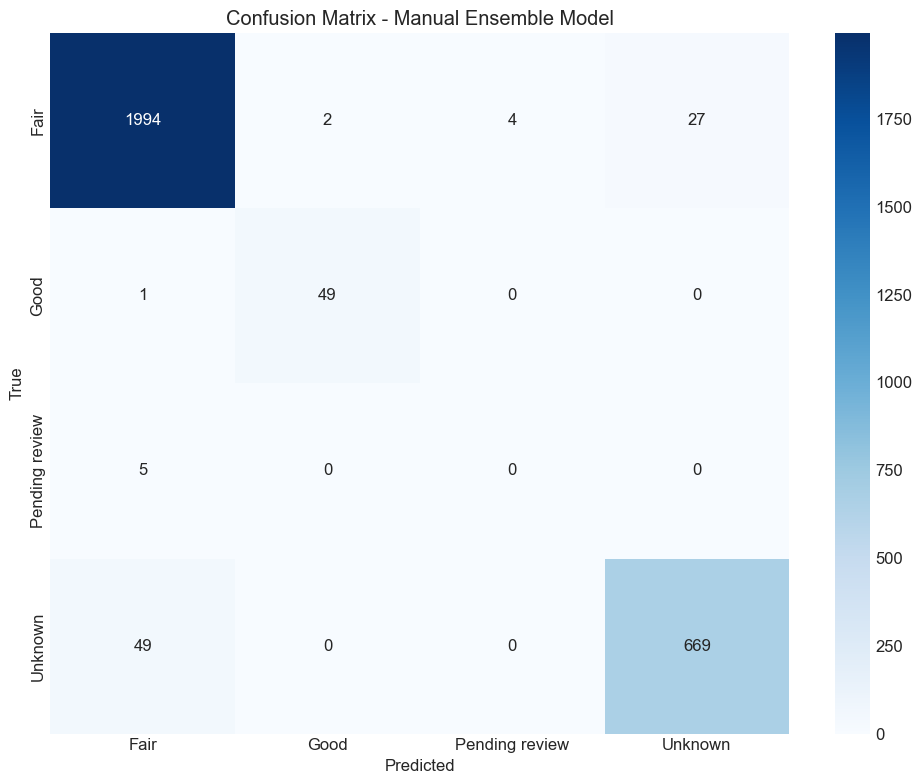

In [19]:
# ==========================================
# ENSEMBLE MODELS
# ==========================================
print("\n" + "="*50)
print("CREATING ENSEMBLE MODEL")
print("="*50)

# Attempt to create a voting ensemble if we have multiple models
if len(tuned_models) > 1:
    from sklearn.ensemble import VotingClassifier
    import types
    
    print("\nCreating a voting ensemble...")
    
    # Patch function for compatibility
    def _patched_sklearn_tags(self):
        return {"estimator_type": "classifier"}
    
    # Create a list of estimators for the voting classifier and patch them
    estimators = []
    for name, model in tuned_models.items():
        # Add __sklearn_tags__ method to model if not exists
        if not hasattr(model, '__sklearn_tags__'):
            model.__sklearn_tags__ = types.MethodType(_patched_sklearn_tags, model)
        estimators.append((name, model))
    
    # Create the voting classifier
    voting_clf = VotingClassifier(
        estimators=estimators,
        voting='soft'  # Use probability-based voting
    )
    
    # Patch the voting classifier too
    if not hasattr(voting_clf, '__sklearn_tags__'):
        voting_clf.__sklearn_tags__ = types.MethodType(_patched_sklearn_tags, voting_clf)
    
    # Fit the voting classifier
    print("Training ensemble model...")
    try:
        voting_clf.fit(X_train_resampled, y_train_resampled)
        
        # Evaluate on validation set
        y_pred_ensemble = voting_clf.predict(X_val)
        f1_ensemble = macro_f1(y_val, y_pred_ensemble)
        
        print(f"  Ensemble Macro F1 on validation set: {f1_ensemble:.4f}")
        
        # Add the ensemble to the models
        tuned_models['Ensemble'] = voting_clf
        
        # Print classification report for the ensemble
        print("\nClassification Report for Ensemble:")
        print(classification_report(y_val, y_pred_ensemble, target_names=le.classes_))
        
        # Plot confusion matrix for the ensemble
        plt.figure(figsize=(10, 8))
        cm = confusion_matrix(y_val, y_pred_ensemble)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.title('Confusion Matrix - Ensemble Model')
        plt.tight_layout()
        plt.savefig('../reports/figures/confusion_matrix_ensemble.png')
        plt.show()
    except Exception as e:
        print(f"Error creating ensemble: {str(e)}")
        print("Using manual ensemble method instead...")
        
        # Manual soft voting implementation
        def predict_proba_all(X):
            """Get probability predictions from all models"""
            all_probs = []
            for name, model in tuned_models.items():
                if hasattr(model, 'predict_proba'):
                    probs = model.predict_proba(X)
                    all_probs.append(probs)
            return all_probs
        
        # Get all probabilities
        val_probs = predict_proba_all(X_val)
        
        # Average probabilities and get predictions
        if val_probs:
            avg_probs = np.mean(val_probs, axis=0)
            y_pred_ensemble = np.argmax(avg_probs, axis=1)
            f1_ensemble = macro_f1(y_val, y_pred_ensemble)
            
            print(f"  Manual Ensemble Macro F1 on validation set: {f1_ensemble:.4f}")
            
            # Add a predict function to use later
            class ManualEnsemble:
                def __init__(self, models):
                    self.models = models
                
                def predict(self, X):
                    all_probs = []
                    for name, model in self.models.items():
                        if hasattr(model, 'predict_proba'):
                            probs = model.predict_proba(X)
                            all_probs.append(probs)
                    
                    if all_probs:
                        avg_probs = np.mean(all_probs, axis=0)
                        return np.argmax(avg_probs, axis=1)
                    else:
                        # Fallback to best model
                        best_model_name = max(tuned_models.items(), 
                                            key=lambda x: macro_f1(y_val, x[1].predict(X_val)))[0]
                        return tuned_models[best_model_name].predict(X)
            
            manual_ensemble = ManualEnsemble(tuned_models)
            tuned_models['Manual Ensemble'] = manual_ensemble
            
            # Print classification report for the ensemble
            print("\nClassification Report for Manual Ensemble:")
            print(classification_report(y_val, y_pred_ensemble, target_names=le.classes_))
            
            # Plot confusion matrix for the ensemble
            plt.figure(figsize=(10, 8))
            cm = confusion_matrix(y_val, y_pred_ensemble)
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
            plt.xlabel('Predicted')
            plt.ylabel('True')
            plt.title('Confusion Matrix - Manual Ensemble Model')
            plt.tight_layout()
            plt.savefig('../reports/figures/confusion_matrix_ensemble.png')
            plt.show()
else:
    print("Only one model available, skipping ensemble creation")

In [20]:
# ==========================================
# GENERATE PREDICTIONS FOR TEST SET
# ==========================================
print("\n" + "="*50)
print("GENERATING PREDICTIONS FOR TEST SET")
print("="*50)

# Choose the best model for final predictions
best_model_perfs = {}
for name, model in tuned_models.items():
    y_pred = model.predict(X_val)
    f1 = macro_f1(y_val, y_pred)
    best_model_perfs[name] = f1

best_model_name = max(best_model_perfs.items(), key=lambda x: x[1])[0]
best_model = tuned_models[best_model_name]
best_f1 = best_model_perfs[best_model_name]

print(f"\nUsing {best_model_name} for final predictions (Validation F1: {best_f1:.4f})")

# Generate predictions
test_preds = best_model.predict(test)
test_preds_labels = le.inverse_transform(test_preds)

# Create submission file
submission = pd.DataFrame({
    'id': sample_submission['id'],
    'Data Quality': test_preds_labels
})

# Save submission file
submission_path = '../data/submissions/submission.csv'
submission.to_csv(submission_path, index=False)
print(f"\nSubmission file saved to: {submission_path}")


GENERATING PREDICTIONS FOR TEST SET

Using Random Forest for final predictions (Validation F1: 0.8011)

Submission file saved to: ../data/submissions/submission.csv


In [21]:
# ==========================================
# SAVE MODELS
# ==========================================
print("\n" + "="*50)
print("SAVING MODELS")
print("="*50)

# Save each tuned model
for name, model in tuned_models.items():
    model_path = f'../models/{name.lower().replace(" ", "_")}_model.pkl'
    joblib.dump(model, model_path)
    print(f"  - {model_path}")



SAVING MODELS
  - ../models/random_forest_model.pkl
  - ../models/xgboost_model.pkl
  - ../models/lightgbm_model.pkl
  - ../models/manual_ensemble_model.pkl


In [24]:
# ==========================================
# SUMMARY
# ==========================================
print("\n" + "="*50)
print("MODEL DEVELOPMENT SUMMARY")
print("="*50)

print("\n1. Baseline Models Performance:")
for name, results in baseline_results.items():
    print(f"  - {name}: Macro F1 = {results['f1']:.4f}")

print("\n2. Tuned Models Performance (Validation Set):")
for name, f1 in best_model_perfs.items():
    print(f"  - {name}: Macro F1 = {f1:.4f}")

print("\n3. Best Model:")
print(f"  - {best_model_name} (Macro F1: {best_f1:.4f})")

print("\nModel development complete! Ready for submission and evaluation.")


MODEL DEVELOPMENT SUMMARY

1. Baseline Models Performance:
  - Random Forest: Macro F1 = 0.7130
  - XGBoost: Macro F1 = 0.7223
  - LightGBM: Macro F1 = 0.7248

2. Tuned Models Performance (Validation Set):
  - Random Forest: Macro F1 = 0.8011
  - XGBoost: Macro F1 = 0.7660
  - LightGBM: Macro F1 = 0.7644
  - Manual Ensemble: Macro F1 = 0.7237

3. Best Model:
  - Random Forest (Macro F1: 0.8011)

Model development complete! Ready for submission and evaluation.
